# Lab 2 Solutions: Pandas for Cat and Dog Faces

These are worked solutions for the Pandas lab. The code below fills in each scaffolded task from the student notebook.

This version is fully independent of Lab 1 and focuses on building, loading, and analyzing metadata with Pandas.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
from lab_utils.visualization import (
    plot_class_balance,
    plot_numeric_distribution,
)

def find_project_root() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "data" / "cats_dogs_faces_small").exists():
            return candidate
    return Path.cwd().resolve()

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "data" / "cats_dogs_faces_small"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

STUDENT_ID = 10422021  # Replace with your own student ID.
SEED = int(STUDENT_ID)
GENERATED_METADATA_PATH = ARTIFACT_DIR / f"lab2_faces_metadata_{STUDENT_ID}.csv"

expected = [
    DATA_ROOT / "train" / "cat",
    DATA_ROOT / "train" / "dog",
    DATA_ROOT / "val" / "cat",
    DATA_ROOT / "val" / "dog",
    DATA_ROOT / "test" / "cat",
    DATA_ROOT / "test" / "dog",
]
if not all(path.exists() for path in expected):
    raise FileNotFoundError(
        "Dataset not found. Run `uv run python scripts/download_animal_faces.py --force` first."
    )

print(f"Student ID seed: {STUDENT_ID}")
print(f"Dataset root: {DATA_ROOT}")
print(f"Generated metadata path: {GENERATED_METADATA_PATH}")


Student ID seed: 10422021
Dataset root: /Users/fuisloy/lab/data/cats_dogs_faces_small
Generated metadata path: /Users/fuisloy/lab/artifacts/lab2_faces_metadata_10422021.csv


## Question 1: Build metadata from the folder structure

Break the metadata-building task into smaller helper functions, then call them from `build_metadata_from_folders(...)`.

Build a dataframe with at least these columns:

- `filepath`
- `label`
- `split`
- `width`
- `height`
- `mean_intensity`

Suggested subtasks:

1. list image paths for one split and one label
2. inspect one image file to get width, height, and mean intensity
3. convert one image path into one metadata row
4. combine all rows into one dataframe


In [2]:
def list_image_paths_for_group(data_root: Path, split: str, label: str) -> list[Path]:
    image_patterns = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
    label_dir = data_root / split / label
    image_paths = []
    for pattern in image_patterns:
        image_paths.extend(sorted(label_dir.glob(pattern)))
    return sorted(image_paths)


def inspect_image_file(path: Path) -> tuple[int, int, float]:
    with Image.open(path) as image:
        image = image.convert("RGB")
        width, height = image.size
        array = np.asarray(image, dtype=np.float32) / 255.0
    return width, height, float(array.mean())


def make_metadata_row(path: Path, data_root: Path, split: str, label: str) -> dict[str, object]:
    width, height, mean_intensity = inspect_image_file(path)
    return {
        "filepath": str(path.relative_to(data_root)),
        "label": label,
        "split": split,
        "width": width,
        "height": height,
        "mean_intensity": mean_intensity,
    }


def build_metadata_from_folders(data_root: Path) -> pd.DataFrame:
    split_names = ("train", "val", "test")
    label_names = ("cat", "dog")
    rows = []

    for split in split_names:
        for label in label_names:
            image_paths = list_image_paths_for_group(data_root, split, label)
            rows.extend([make_metadata_row(path, data_root, split, label) for path in image_paths])

    return pd.DataFrame(rows).sort_values(["split", "label", "filepath"]).reset_index(drop=True)


folder_df = build_metadata_from_folders(DATA_ROOT)
print("metadata shape:", folder_df.shape)
display(folder_df.head())

folder_df.to_csv(GENERATED_METADATA_PATH, index=False)
print(f"Saved generated metadata to: {GENERATED_METADATA_PATH}")


metadata shape: (600, 6)


,filepath,label,split,width,height,mean_intensity
0,test/cat/cat_0000.jpg,cat,test,64,64,0.523017
1,test/cat/cat_0001.jpg,cat,test,64,64,0.461298
2,test/cat/cat_0002.jpg,cat,test,64,64,0.444787
3,test/cat/cat_0003.jpg,cat,test,64,64,0.523841
4,test/cat/cat_0004.jpg,cat,test,64,64,0.390539


Saved generated metadata to: /Users/fuisloy/lab/artifacts/lab2_faces_metadata_10422021.csv


## Question 2: Load the saved metadata with Pandas

Use `pd.read_csv(...)` inside a small helper function.

This keeps the workflow realistic: build a table once, then reload it as a dataframe for analysis.


In [3]:
def load_metadata_table(csv_path: Path) -> pd.DataFrame:
    return pd.read_csv(csv_path)


df = load_metadata_table(GENERATED_METADATA_PATH)
print("loaded shape:", df.shape)
display(df.head())


loaded shape: (600, 6)


,filepath,label,split,width,height,mean_intensity
0,test/cat/cat_0000.jpg,cat,test,64,64,0.523017
1,test/cat/cat_0001.jpg,cat,test,64,64,0.461298
2,test/cat/cat_0002.jpg,cat,test,64,64,0.444787
3,test/cat/cat_0003.jpg,cat,test,64,64,0.523841
4,test/cat/cat_0004.jpg,cat,test,64,64,0.390539


## Question 3: Inspect the metadata table

Summarize the dataset with Pandas operations. Return:

- number of rows
- column names
- class counts
- split counts


In [4]:
def summarize_metadata(frame: pd.DataFrame) -> dict[str, object]:
    return {
        "rows": len(frame),
        "columns": frame.columns.tolist(),
        "class_counts": frame["label"].value_counts().sort_index(),
        "split_counts": frame["split"].value_counts().sort_index(),
    }


metadata_summary = summarize_metadata(df)
print("Rows:", metadata_summary["rows"])
print("Columns:", metadata_summary["columns"])
print("\nClass counts:")
print(metadata_summary["class_counts"])
print("\nSplit counts:")
print(metadata_summary["split_counts"])


Rows: 600
Columns: ['filepath', 'label', 'split', 'width', 'height', 'mean_intensity']

Class counts:
label
cat    300
dog    300
Name: count, dtype: int64

Split counts:
split
test      90
train    420
val       90
Name: count, dtype: int64


## Question 4: Count each split by class

Build a table that answers questions like:

- how many dog images are in `train`?
- how many dog images are in `val`?
- how many dog images are in `test`?
- and the same for cats

Hint:

Use `groupby(["label", "split"]).size().unstack(fill_value=0)` inside your helper function.


In [ ]:
def build_label_split_table(frame: pd.DataFrame) -> pd.DataFrame:
    return frame.groupby(["label", "split"]).size().unstack(fill_value=0)


label_split_table = build_label_split_table(df)
display(label_split_table)


## Question 5: Audit metadata quality

Check for:

- missing values
- duplicated file paths
- unexpected labels
- non-positive image sizes


In [5]:
def audit_metadata(frame: pd.DataFrame) -> dict[str, object]:
    return {
        "missing_values": frame.isna().sum().to_dict(),
        "duplicate_filepaths": int(frame["filepath"].duplicated().sum()),
        "bad_labels": frame.loc[~frame["label"].isin(["cat", "dog"]), "label"].unique().tolist(),
        "non_positive_sizes": int(((frame["width"] <= 0) | (frame["height"] <= 0)).sum()),
    }


audit_report = audit_metadata(df)
audit_report


{'missing_values': {'filepath': 0,
  'label': 0,
  'split': 0,
  'width': 0,
  'height': 0,
  'mean_intensity': 0},
 'duplicate_filepaths': 0,
 'bad_labels': [],
 'non_positive_sizes': 0}

## Question 6: Add analysis columns

Create a helper function that returns a copy of the dataframe with these new columns:

- `pixel_count = width * height`
- `aspect_ratio = width / height`
- `brightness_band` using `pd.qcut(...)` with 4 bins
- `size_bucket` using labels like `small`, `medium`, and `large`


In [6]:
def add_analysis_columns(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    result["pixel_count"] = result["width"] * result["height"]
    result["aspect_ratio"] = result["width"] / result["height"]
    result["brightness_band"] = pd.qcut(
        result["mean_intensity"],
        q=4,
        labels=["darkest", "dim", "bright", "brightest"],
        duplicates="drop",
    )
    size_reference_pixels = 64 * 64
    result["size_bucket"] = np.select(
        [
            result["pixel_count"] < size_reference_pixels,
            result["pixel_count"] == size_reference_pixels,
            result["pixel_count"] > size_reference_pixels,
        ],
        ["small", "medium", "large"],
        default="unknown",
    )
    return result


analysis_df = add_analysis_columns(df)
display(analysis_df.head())


,filepath,label,split,width,height,mean_intensity,pixel_count,aspect_ratio,brightness_band,size_bucket
0,test/cat/cat_0000.jpg,cat,test,64,64,0.523017,4096,1.0,brightest,medium
1,test/cat/cat_0001.jpg,cat,test,64,64,0.461298,4096,1.0,bright,medium
2,test/cat/cat_0002.jpg,cat,test,64,64,0.444787,4096,1.0,dim,medium
3,test/cat/cat_0003.jpg,cat,test,64,64,0.523841,4096,1.0,brightest,medium
4,test/cat/cat_0004.jpg,cat,test,64,64,0.390539,4096,1.0,dim,medium


## Question 7: Visualize the data split

Build a split-balance table that counts cats and dogs inside each split, then visualize it.

Hint:

Use `groupby(["split", "label"]).size().unstack(fill_value=0)` inside your helper function.


label,cat,dog
split,,
test,45,45
train,210,210
val,45,45


(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'Class balance by split'}, xlabel='split', ylabel='Images'>)

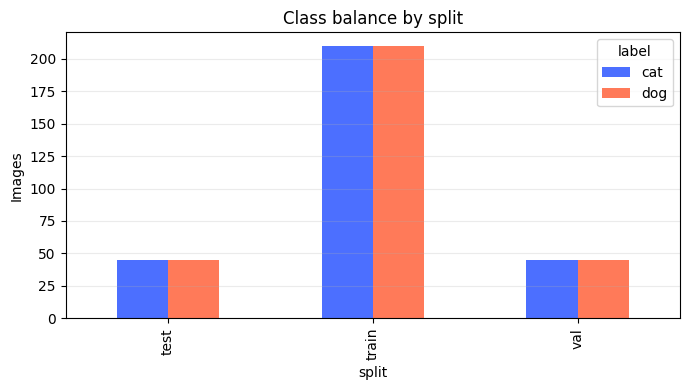

In [7]:
def build_split_balance_table(frame: pd.DataFrame) -> pd.DataFrame:
    return frame.groupby(["split", "label"]).size().unstack(fill_value=0)


split_balance = build_split_balance_table(analysis_df)
display(split_balance)

plot_class_balance(analysis_df, title="Class balance by split")


## Question 8: Create a balanced sample by split and class

Build a smaller dataframe for quick experiments.

Requirement:

Sample the same number of images for each `(split, label)` group so the sample stays balanced across both the data split and the class.

Suggested property to preserve:

- every split should still contain both cats and dogs
- each `(split, label)` group should contribute the same number of rows

Hint:

Use `groupby(["split", "label"])` and sample within each group with a fixed random seed.



intensity_by_split_label:


label,cat,dog
split,,
test,0.475375,0.423208
train,0.452452,0.455363
val,0.439099,0.465935



size_by_split:


width         height         pixel_count            
       mean min max   mean min max        mean   min   max
split                                                     
test   64.0  64  64   64.0  64  64      4096.0  4096  4096
train  64.0  64  64   64.0  64  64      4096.0  4096  4096
val    64.0  64  64   64.0  64  64      4096.0  4096  4096


brightness_by_label:


brightness_band,darkest,dim,bright,brightest
label,,,,
cat,80,71,72,77
dog,70,79,78,73


(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'Mean intensity by label'}, xlabel='mean_intensity', ylabel='Count'>)

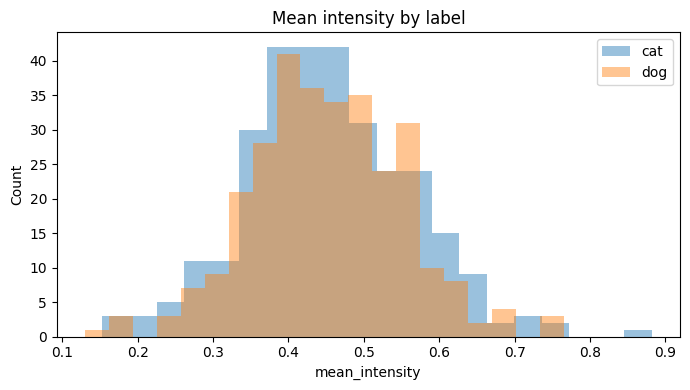

In [8]:
def sample_balanced_by_split_and_label(frame: pd.DataFrame, n_per_group: int, seed: int) -> pd.DataFrame:
    sampled = (
        frame.groupby(["split", "label"], group_keys=False)
        .apply(lambda group: group.sample(n=min(n_per_group, len(group)), random_state=seed))
        .reset_index(drop=True)
    )
    return sampled.sort_values(["split", "label", "filepath"]).reset_index(drop=True)


sample_size_per_group = 5
sampled_df = sample_balanced_by_split_and_label(analysis_df, n_per_group=sample_size_per_group, seed=SEED)
print("sampled shape:", sampled_df.shape)
display(sampled_df.head())

sampled_balance = sampled_df.groupby(["split", "label"]).size().unstack(fill_value=0)
display(sampled_balance)

plot_class_balance(sampled_df, title="Balanced sampled subset by split")


## Reflection

Write short answers to these questions:

1. Is the dataset balanced across classes and splits?
2. Did your sampled subset stay balanced across splits and classes?
3. Why is grouped sampling useful before training a model?
4. Which Pandas operation felt most useful in this lab: `groupby`, `value_counts`, `qcut`, or sampling within groups? Why?
